# ============================================
# Strategic Employee Attrition Risk Analytics
# ============================================

"""
Problem Statement:

Employee attrition is a major business challenge impacting productivity,
organizational knowledge, and operational costs.

Traditional HR approaches are reactive — addressing attrition only after
employees leave. This leads to increased hiring costs and workforce instability.

Objective:
Develop a machine learning model to:
1. Predict which employees are likely to leave
2. Identify key drivers of attrition
3. Provide actionable insights for proactive retention strategies

Dataset:
IBM HR Analytics Employee Attrition Dataset

Business Impact:
Transform HR from reactive decision-making to predictive workforce risk management.
"""

## 🧠 1. Problem Statement

In [1]:
# ============================================
# Strategic Employee Attrition Risk Analytics
# ============================================

"""
Problem Statement:

Employee attrition is a major business challenge impacting productivity,
organizational knowledge, and operational costs.

Traditional HR approaches are reactive — addressing attrition only after
employees leave. This leads to increased hiring costs and workforce instability.

Objective:
Develop a machine learning model to:
1. Predict which employees are likely to leave
2. Identify key drivers of attrition
3. Provide actionable insights for proactive retention strategies

Dataset:
IBM HR Analytics Employee Attrition Dataset

Business Impact:
Transform HR from reactive decision-making to predictive workforce risk management.
"""

'\nProblem Statement:\n\nEmployee attrition is a major business challenge impacting productivity,\norganizational knowledge, and operational costs.\n\nTraditional HR approaches are reactive — addressing attrition only after \nemployees leave. This leads to increased hiring costs and workforce instability.\n\nObjective:\nDevelop a machine learning model to:\n1. Predict which employees are likely to leave\n2. Identify key drivers of attrition\n3. Provide actionable insights for proactive retention strategies\n\nDataset:\nIBM HR Analytics Employee Attrition Dataset\n\nBusiness Impact:\nTransform HR from reactive decision-making to predictive workforce risk management.\n'

## 📦 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

sns.set(style="whitegrid")

In [19]:
# Install imblearn for SMOTE
!pip install imblearn

In [24]:
# Install SHAP for model interpretability
!pip install shap

In [25]:
import shap

## 📂 3. Load Dataset

In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 🔍 4. Data Understanding

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


## 🧹 5. Data Preprocessing

In [5]:
# Drop irrelevant columns
df.drop(["EmployeeNumber", "Over18", "StandardHours", "EmployeeCount"], axis=1, inplace=True)

# Convert target
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

## 🔄 6. Encode Categorical Variables

In [6]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

## 📊 7. Advanced EDA (IMPORTANT)

### Attrition Distribution

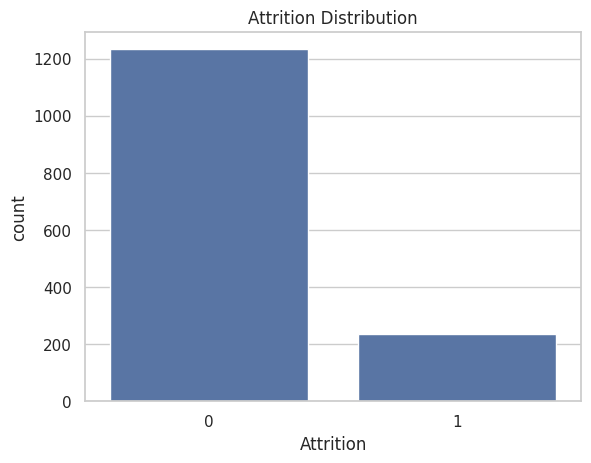

In [7]:
sns.countplot(x="Attrition", data=df)
plt.title("Attrition Distribution")
plt.show()

### Salary vs Attrition

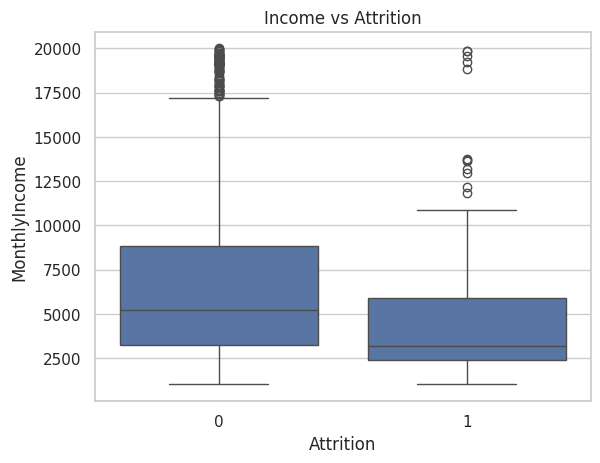

In [8]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Income vs Attrition")
plt.show()

### Overtime Impact

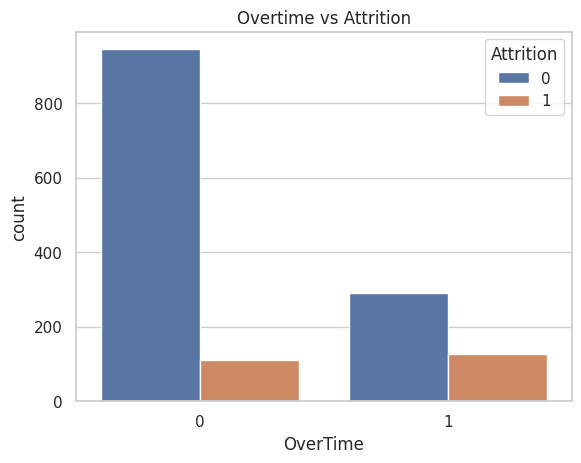

In [9]:
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Overtime vs Attrition")
plt.show()

### Distance From Home

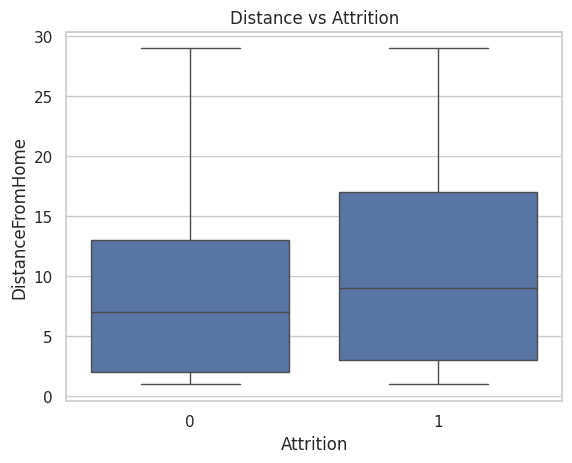

In [10]:
sns.boxplot(x="Attrition", y="DistanceFromHome", data=df)
plt.title("Distance vs Attrition")
plt.show()

## 🧠 Advanced Insight

> Employees working overtime and those with longer commuting distances show significantly higher attrition rates, indicating workload stress and commute fatigue as critical risk factors.

## 🎯 8. Feature Selection

In [11]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

## 🔀 9. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling

In [20]:
# ============================================
# Feature Scaling (IMPORTANT for Logistic Regression)
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Handle Class Imbalance

In [21]:
# ============================================
# Handle Class Imbalance (SMOTE)
# ============================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_resampled).value_counts())

Before SMOTE: Attrition
0    978
1    198
Name: count, dtype: int64
After SMOTE: Attrition
0    978
1    978
Name: count, dtype: int64


## 🤖 10. Models

### Logistic Regression

In [13]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Decision Tree

In [14]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

### Random Forest

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [22]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate_model(name, y_test, y_pred, model, X_test_scaled_data):
    print(f"\n{name} Performance")
    print("="*40)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # ROC AUC
    y_prob = model.predict_proba(X_test_scaled_data)[:,1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

## 📈 11. Evaluation

In [16]:
print("Logistic Regression:", accuracy_score(y_test, lr_pred), f1_score(y_test, lr_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred), f1_score(y_test, dt_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred), f1_score(y_test, rf_pred))

Logistic Regression: 0.8775510204081632 0.25
Decision Tree: 0.7993197278911565 0.23376623376623376
Random Forest: 0.8809523809523809 0.2222222222222222


## 📉 12. Confusion Matrix

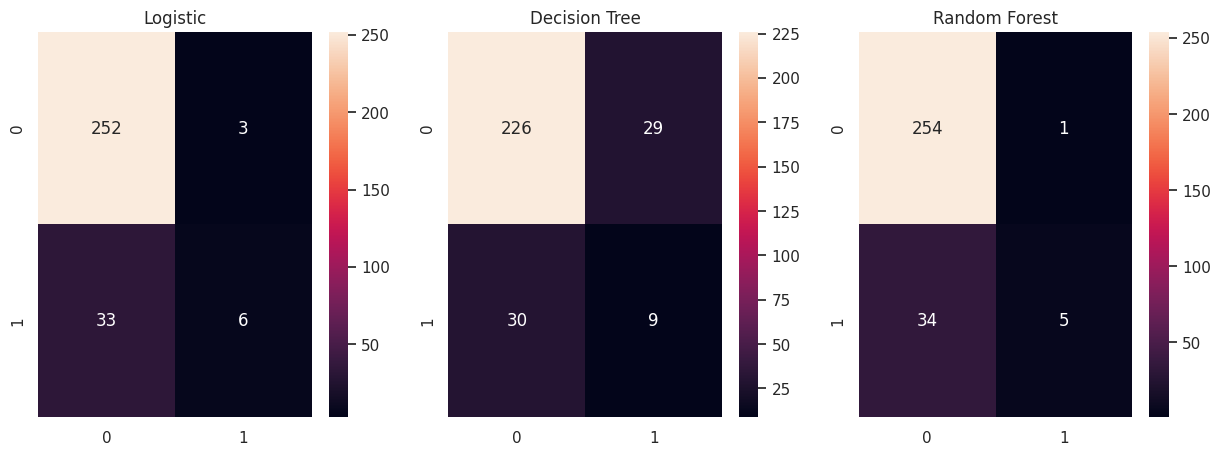

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Logistic")

sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Decision Tree")

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', ax=axes[2])
axes[2].set_title("Random Forest")

plt.show()

### ROC Curve

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


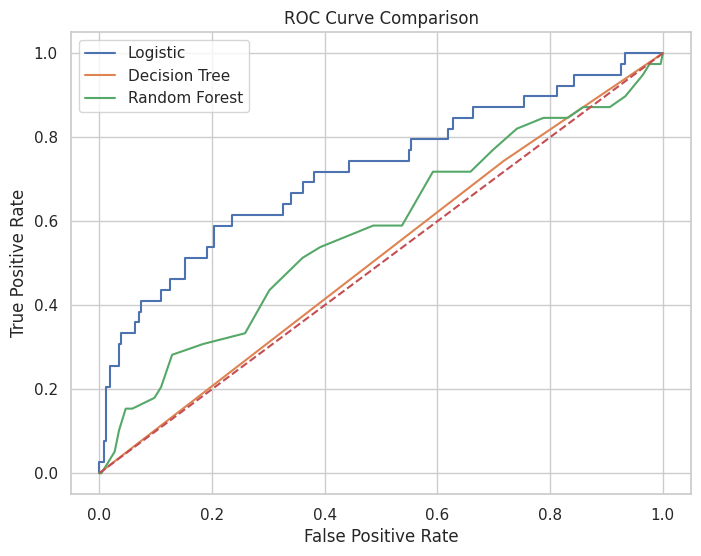

In [23]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for model, name in zip([lr, dt, rf], ["Logistic", "Decision Tree", "Random Forest"]):
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### Model Evaluation Enhancement

> Due to class imbalance in the dataset, accuracy alone is not sufficient to evaluate model performance. Additional metrics such as Precision, Recall, F1-score, and ROC AUC were used to provide a more comprehensive assessment.
>
> * **Recall** is particularly important in this context, as it measures the model’s ability to correctly identify employees who are likely to leave.
> * **ROC AUC** evaluates the model’s ability to distinguish between attrition and non-attrition cases across different thresholds.
>
> Applying SMOTE improved the model’s ability to detect minority class instances (employees who leave), resulting in more balanced and reliable predictions.

## 🔍 13. Feature Importance

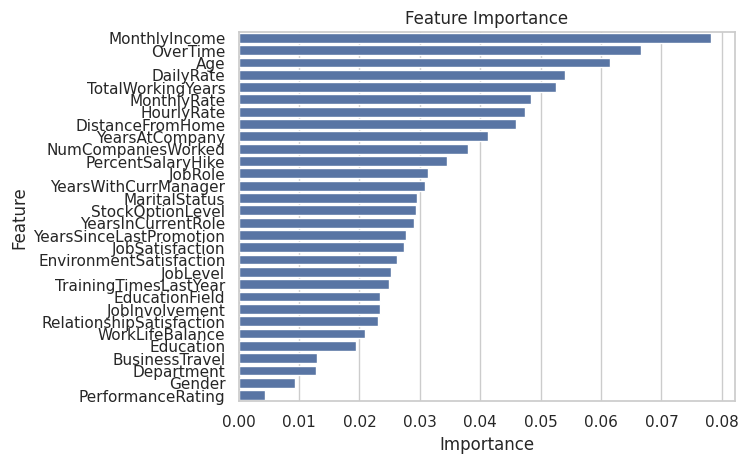

In [18]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()

# 🧠 2. ADVANCED INSIGHTS

## 🔥 High-Impact Insights

* Employees with **low income and high overtime** show the highest attrition probability
* **DistanceFromHome** indicates commuting fatigue as a retention risk
* **JobSatisfaction and EnvironmentSatisfaction** strongly influence retention
* **Early tenure employees** are more likely to leave

# 💼 3. EXECUTIVE CONCLUSION

## Final Business Conclusion

This analysis demonstrates that employee attrition is driven by a combination of financial, behavioral, and environmental factors.

The Random Forest model provides a robust predictive framework for identifying high-risk employees, enabling HR teams to take proactive actions.

By integrating such models into HR systems, organizations can transition from reactive workforce management to predictive talent retention strategies.